<a href="https://colab.research.google.com/github/SamiulAhmedTamim/DatasetDiscoveryAndIngestionSystem/blob/main/AI_FAIRNESS_FINAL_CODEBLOCK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Census-based division weights: {'Dhaka': 0.2688, 'Chattogram': 0.2013, 'Rajshahi': 0.1224, 'Khulna': 0.1049, 'Rangpur': 0.1061, 'Sylhet': 0.0672, 'Barishal': 0.0549, 'Mymensingh': 0.0744}
Applicant-pool female share (derived): 0.312

Running main pipeline (n=50,000, logistic regression)...

=== Main summary table ===
             scenario  SPD_gender  EOD_gender  SPD_region  EOD_region  IDI_logit  IDI_prob  IDI_noise_floor_95  IDI_p_vs_no_interaction    DF  Bias_Index_gender  Bias_Index_region  Fairness_Score  PDPO_Score  Regulatory_Alignment_Score
        baseline_fair       0.009       0.008       0.268       0.268      0.005     0.001               0.082                    0.892 0.647              0.000              0.000           1.000       1.000                       1.000
        gender_biased       0.224       0.209       0.249       0.261      0.229     0.026               0.179                    0.006 1.597              0.247              0.021           0.825       0.952  

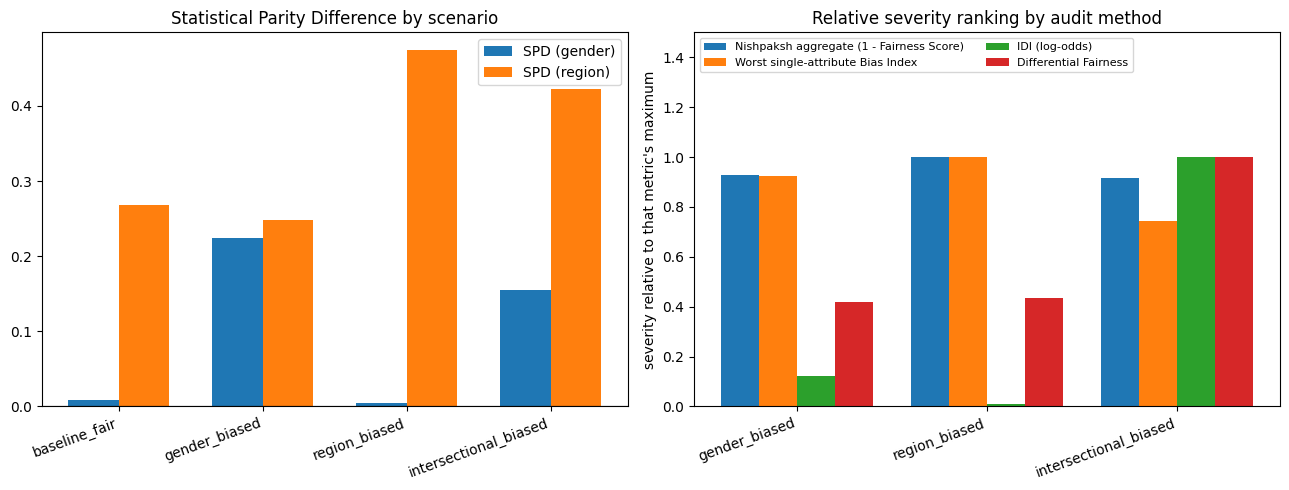


PDPO_Score by scenario:
             scenario  PDPO_Score
        baseline_fair       1.000
        gender_biased       0.952
        region_biased       0.952
intersectional_biased       0.857


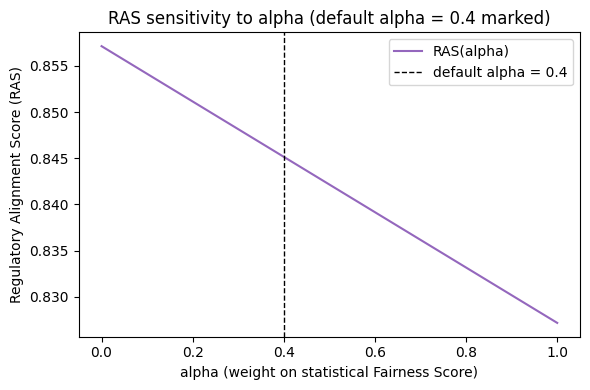


=== Intersectional subgroup table (intersectional_biased) ===
 gender_female  is_peripheral  observed_rate  predicted_additive_logit  predicted_additive_prob  interaction_term_logit  share_of_population
             0              0          0.594                     0.391                    0.596                  -0.009                0.482
             0              1          0.178                    -1.742                    0.149                   0.210                0.206
             1              0          0.446                    -0.268                    0.433                   0.052                0.217
             1              1          0.013                    -2.400                    0.083                  -1.905                0.095


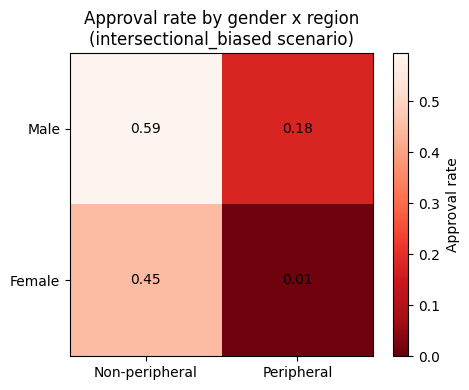


Gradient-boosted-trees pipeline (robustness check)...
             scenario  IDI_prob    DF  Bias_Index_gender  Bias_Index_region  PDPO_Score
        baseline_fair     0.002 0.650              0.000              0.000       1.000
        gender_biased     0.021 1.556              0.234              0.013       0.952
        region_biased     0.009 1.666              0.010              0.263       0.952
intersectional_biased     0.069 3.727              0.141              0.191       0.857

Rank check under gradient-boosted trees:
{
  "ranking_by_Nishpaksh_FS_severity": [
    "region_biased",
    "intersectional_biased",
    "gender_biased"
  ],
  "ranking_by_max_single_attribute_BI": [
    "region_biased",
    "gender_biased",
    "intersectional_biased"
  ],
  "ranking_by_IDI_logit": [
    "intersectional_biased",
    "gender_biased",
    "region_biased"
  ],
  "ranking_by_IDI_prob": [
    "intersectional_biased",
    "gender_biased",
    "region_biased"
  ],
  "ranking_by_DF": [
   

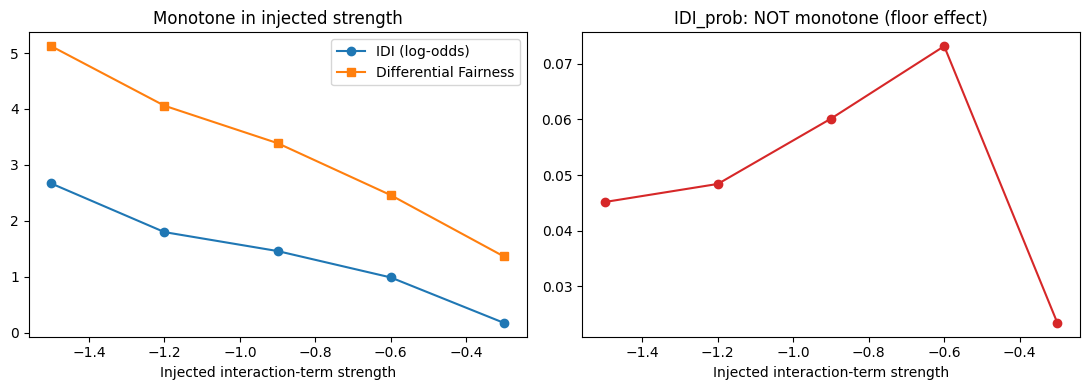

IDI_prob rises then falls because as the (female, peripheral) approval rate approaches 0 the probability-scale gap to the additive prediction shrinks (floor effect). Report IDI (log-odds) or DF as the primary intensity measure; use IDI_prob only for same-units comparisons at moderate bias levels.

Peripheral-definition sensitivity...
Rank 1 = judged MOST severe of the three biased scenarios. The claim needs rank>1 under Nishpaksh FS and rank 1 under IDI/DF.
                                            peripheral_definition  rank_of_intersectional_by_Nishpaksh_FS  rank_by_max_single_attr_BI  rank_by_IDI_logit  rank_by_IDI_prob  rank_by_DF                                                                   FS_by_scenario
           core4 (default): Rangpur, Barishal, Sylhet, Mymensingh                                       2                           3                  1                 1           1 {'gender_biased': 0.805, 'region_biased': 0.826, 'intersectional_biased': 0.826}
excl. Sylh

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "pandas", "numpy", "matplotlib", "scipy"],
               check=False)


import json
import os
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
RNG_SEED = 42
np.random.seed(RNG_SEED)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")


CENSUS_2022_DIVISION_POP = {
    "Dhaka": 45_643_915, "Chattogram": 34_178_580, "Rajshahi": 20_794_023,
    "Khulna": 17_813_958, "Rangpur": 18_020_074, "Sylhet": 11_415_021,
    "Barishal": 9_325_818, "Mymensingh": 12_637_525,
}
_POP_TOTAL = sum(CENSUS_2022_DIVISION_POP.values())
DIVISION_WEIGHTS = {k: v / _POP_TOTAL for k, v in CENSUS_2022_DIVISION_POP.items()}

PERIPHERAL_DIVISIONS = {"Rangpur", "Barishal", "Sylhet", "Mymensingh"}

_M_SHARE, _F_SHARE = 0.4951, 0.5043
APPLICANT_FEMALE_SHARE_DEFAULT = (0.20 * _F_SHARE) / (0.45 * _M_SHARE + 0.20 * _F_SHARE)

INCOME_CENTRAL, INCOME_OTHER = 28000, 16000
EDUCATION_PROBS_DEFAULT = [0.10, 0.25, 0.30, 0.20, 0.15]
AGE_MEAN_DEFAULT, AGE_SD_DEFAULT = 34, 10

GENDER_BIAS_STRENGTH_DEFAULT = -0.6
REGION_BIAS_STRENGTH_DEFAULT = -0.6
INTERSECTIONAL_STRENGTHS_DEFAULT = (-0.30, -0.30, -0.9)


def generate_bd_loan_dataset(
    n_samples: int,
    scenario: str,
    seed: int = RNG_SEED,
    gender_bias_strength: float = GENDER_BIAS_STRENGTH_DEFAULT,
    region_bias_strength: float = REGION_BIAS_STRENGTH_DEFAULT,
    intersectional_strengths: tuple = INTERSECTIONAL_STRENGTHS_DEFAULT,
    division_weights: dict = None,
    peripheral_divisions: set = None,
    female_share: float = None,
    education_probs: list = None,
    age_mean: float = AGE_MEAN_DEFAULT,
    age_sd: float = AGE_SD_DEFAULT,
) -> pd.DataFrame:
    """Synthetic BD MFS loan-approval dataset with a known latent creditworthiness
    score, so injected bias is measurable against a transparent ground truth.
    Every demographic and bias parameter is an argument, so the Findex
    calibration (Section 12) and the sweeps (Section 10) reuse this function."""
    rng = np.random.default_rng(seed)
    division_weights = division_weights or DIVISION_WEIGHTS
    peripheral_divisions = PERIPHERAL_DIVISIONS if peripheral_divisions is None else peripheral_divisions
    female_share = APPLICANT_FEMALE_SHARE_DEFAULT if female_share is None else female_share
    education_probs = education_probs or EDUCATION_PROBS_DEFAULT

    divisions = rng.choice(list(division_weights.keys()), size=n_samples, p=list(division_weights.values()))
    is_peripheral = np.array([d in peripheral_divisions for d in divisions])
    gender = rng.choice(["Male", "Female"], size=n_samples, p=[1 - female_share, female_share])
    age = np.clip(rng.normal(age_mean, age_sd, n_samples), 18, 70).round().astype(int)

    education = rng.choice(
        ["No Formal", "Primary", "Secondary", "Higher Secondary", "Graduate"],
        size=n_samples, p=education_probs,
    )
    edu_score = pd.Series(education).map(
        {"No Formal": 0, "Primary": 1, "Secondary": 2, "Higher Secondary": 3, "Graduate": 4}
    ).values

    emp_years = np.clip(rng.exponential(4, n_samples), 0, 35)
    base_income = np.where(np.isin(divisions, ["Dhaka", "Chattogram"]), INCOME_CENTRAL, INCOME_OTHER)
    income = np.clip(rng.normal(base_income, 9000), 4000, 200000)
    credit_history = rng.choice([0, 1], size=n_samples, p=[0.22, 0.78])

    z = (
        0.35 * (income / income.std()) + 0.25 * (edu_score / 4)
        + 0.20 * (emp_years / emp_years.std()) + 0.30 * credit_history
        - 0.15 * (age > 55).astype(int)
    )
    z = (z - z.mean()) / z.std()

    female = (gender == "Female").astype(int)
    peripheral = is_peripheral.astype(int)

    if scenario == "baseline_fair":
        bias_term = np.zeros(n_samples)
    elif scenario == "gender_biased":
        bias_term = gender_bias_strength * female
    elif scenario == "region_biased":
        bias_term = region_bias_strength * peripheral
    elif scenario == "intersectional_biased":
        s_f, s_p, s_int = intersectional_strengths
        bias_term = s_f * female + s_p * peripheral + s_int * (female * peripheral)
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    logit = 0.9 * z + bias_term
    prob_approve = 1 / (1 + np.exp(-logit))
    approved = rng.binomial(1, prob_approve)

    df = pd.DataFrame({
        "division": divisions, "is_peripheral": is_peripheral.astype(int), "gender": gender,
        "age": age, "education": education, "education_score": edu_score,
        "employment_years": emp_years.round(1), "monthly_income_bdt": income.round(0),
        "credit_history_clean": credit_history, "true_creditworthiness_z": z.round(3),
        "loan_approved": approved,
    })
    df.attrs["scenario"] = scenario
    return df


print("Census-based division weights:", {k: round(v, 4) for k, v in DIVISION_WEIGHTS.items()})
print(f"Applicant-pool female share (derived): {APPLICANT_FEMALE_SHARE_DEFAULT:.3f}")



BASE_FEATURES = ["age", "education_score", "employment_years", "monthly_income_bdt", "credit_history_clean"]

SCENARIO_MODEL_FEATURES = {
    "baseline_fair": BASE_FEATURES,
    "gender_biased": BASE_FEATURES + ["gender_female"],
    "region_biased": BASE_FEATURES + ["is_peripheral"],
    "intersectional_biased": BASE_FEATURES + ["gender_female", "is_peripheral", "gender_x_peripheral"],
}


def _add_model_encodings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["gender_female"] = (df["gender"] == "Female").astype(int)
    df["gender_x_peripheral"] = df["gender_female"] * df["is_peripheral"]
    return df


def train_model(df: pd.DataFrame, scenario: str, seed: int = RNG_SEED, model_type: str = "logreg"):
    """model_type: 'logreg' or 'gbt'."""
    df = _add_model_encodings(df)
    feature_cols = SCENARIO_MODEL_FEATURES[scenario]

    X = df[feature_cols].values
    y = df["loan_approved"].values
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, df.index, test_size=0.3, random_state=seed, stratify=y
    )
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    if model_type == "logreg":
        clf = LogisticRegression(max_iter=1000, random_state=seed, C=0.5)
    elif model_type == "gbt":
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=150, max_depth=3)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    test_df = df.loc[idx_test].copy()
    test_df["y_true"] = y_test
    test_df["y_pred"] = y_pred
    return clf, test_df


def _rate(df, col, value=1, laplace_smoothing=False):
    sub = df[df[col] == value]
    if sub.empty:
        return np.nan
    if laplace_smoothing:
        n_pos = sub["y_pred"].sum()
        n = len(sub)
        return (n_pos + 1) / (n + 2)
    return sub["y_pred"].mean()


def _tpr_fpr(df, group_val, group_col):
    g = df[df[group_col] == group_val]
    pos = g[g["y_true"] == 1]
    neg = g[g["y_true"] == 0]
    tpr = pos["y_pred"].mean() if len(pos) else np.nan
    fpr = neg["y_pred"].mean() if len(neg) else np.nan
    return tpr, fpr


def compute_fairness_metrics(df, group_col, privileged_val, unprivileged_val) -> dict:
    p1 = _rate(df, group_col, privileged_val)
    p0 = _rate(df, group_col, unprivileged_val)
    spd = p1 - p0

    p1_s = _rate(df, group_col, privileged_val, laplace_smoothing=True)
    p0_s = _rate(df, group_col, unprivileged_val, laplace_smoothing=True)
    di = p1_s / p0_s
    ndi = di - 1

    tpr1, fpr1 = _tpr_fpr(df, privileged_val, group_col)
    tpr0, fpr0 = _tpr_fpr(df, unprivileged_val, group_col)
    eod = tpr1 - tpr0
    aod = 0.5 * ((fpr1 - fpr0) + (tpr1 - tpr0))
    eo = abs(fpr1 - fpr0) + abs(tpr1 - tpr0)

    return {"SPD": spd, "DI": di, "NDI": ndi, "EOD": eod, "AOD": aod, "EO": eo,
            "FPR_priv": fpr1, "FPR_unpriv": fpr0, "TPR_priv": tpr1, "TPR_unpriv": tpr0}


def bootstrap_ci(df, group_col, privileged_val, unprivileged_val, metric="SPD", n_boot=500, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    vals, n = [], len(df)
    for _ in range(n_boot):
        sample = df.iloc[rng.integers(0, n, n)]
        vals.append(compute_fairness_metrics(sample, group_col, privileged_val, unprivileged_val)[metric])
    vals = np.array([v for v in vals if not np.isnan(v)])
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(np.mean(vals)), float(lo), float(hi)


def bias_index(model_metrics, baseline_metrics, metric_keys=("SPD", "EOD", "AOD", "EO")) -> float:
    """Eq.(6) of Nishpaksh. NDI/DI deliberately excluded (unbounded ratio
    metric can explode near-zero subgroup rates and destabilise the index)."""
    diffs = [(model_metrics[k] - baseline_metrics[k]) ** 2 for k in metric_keys
             if not np.isnan(model_metrics[k]) and not np.isnan(baseline_metrics[k])]
    return float(np.sqrt(np.mean(diffs))) if diffs else np.nan


def fairness_score(bias_indices) -> float:
    """Eq.(7) of Nishpaksh: FS = 1 - sqrt(mean(BI_i^2))."""
    bi = np.array([b for b in bias_indices if not np.isnan(b)])
    return float(1 - np.sqrt(np.mean(bi ** 2))) if len(bi) else np.nan


# -----------------------------------------------------------------------------
# Modification 3a: Monte-Carlo noise floor for IDI (core metrics section)
# -----------------------------------------------------------------------------

def idi_noise_floor_from_df(df, attr_a="gender_female", attr_b="is_peripheral",
                            n_sim=2000, seed=RNG_SEED):
    """Noise floor for IDI_logit. Simulates the no-interaction null: cell
    approval rates drawn from the additive-in-logit prediction implied by the
    observed margins, with observed cell sizes. Returns observed IDI_logit,
    null median, null 95th percentile, and a Monte-Carlo p-value. Report this
    alongside every IDI estimate; IDI is an absolute value, so pure noise
    produces IDI > 0 and the bootstrap CI cannot exclude 0."""
    eps = 1e-4
    logit = lambda p: float(np.log(np.clip(p, eps, 1 - eps) / (1 - np.clip(p, eps, 1 - eps))))
    sig = lambda l: float(1 / (1 + np.exp(-l)))

    g = df.groupby([attr_a, attr_b])
    rate = {k: float(v["y_pred"].mean()) for k, v in g}
    count = {k: int(len(v)) for k, v in g}
    if len(rate) < 4:
        return {"observed_IDI_logit": np.nan, "null_median": np.nan,
                "null_95th_percentile": np.nan, "p_value_vs_no_interaction": np.nan}

    def _idi_from_rates(r, c):
        W = sum(c.values())
        ov = sum(c[k] * r[k] for k in r) / W
        def m(ax, v):
            ks = [k for k in r if k[ax] == v]
            return sum(c[k] * r[k] for k in ks) / sum(c[k] for k in ks)
        a11 = logit(m(0, 1)) + logit(m(1, 1)) - logit(ov)
        return abs(logit(r[(1, 1)]) - a11), ov, m

    obs_idi, ov, m = _idi_from_rates(rate, count)
    p0 = {k: sig(logit(m(0, k[0])) + logit(m(1, k[1])) - logit(ov)) for k in rate}

    rng = np.random.default_rng(seed)
    sims = []
    for _ in range(n_sim):
        r = {k: rng.binomial(count[k], p0[k]) / count[k] for k in rate}
        sim_idi, _, _ = _idi_from_rates(r, count)
        sims.append(sim_idi)
    sims = np.array(sims)
    return {
        "observed_IDI_logit": float(obs_idi),
        "null_median": float(np.median(sims)),
        "null_95th_percentile": float(np.percentile(sims, 95)),
        "p_value_vs_no_interaction": float((sims >= obs_idi).mean()),
    }




def intersectional_disparity_index(df, attr_a="gender_female", attr_b="is_peripheral") -> dict:
    eps = 1e-4
    def _logit(p):
        p = np.clip(p, eps, 1 - eps)
        return float(np.log(p / (1 - p)))
    def _sigmoid(l):
        return float(1 / (1 + np.exp(-l)))

    overall_rate = df["y_pred"].mean()
    rate_a1 = df.loc[df[attr_a] == 1, "y_pred"].mean()
    rate_a0 = df.loc[df[attr_a] == 0, "y_pred"].mean()
    rate_b1 = df.loc[df[attr_b] == 1, "y_pred"].mean()
    rate_b0 = df.loc[df[attr_b] == 0, "y_pred"].mean()

    grouped = df.groupby([attr_a, attr_b])
    observed = grouped["y_pred"].mean()
    weights = grouped.size() / len(df)

    l_overall, l_a1, l_a0, l_b1, l_b0 = map(_logit, (overall_rate, rate_a1, rate_a0, rate_b1, rate_b0))
    predicted_additive_logit = {
        (0, 0): l_a0 + l_b0 - l_overall, (0, 1): l_a0 + l_b1 - l_overall,
        (1, 0): l_a1 + l_b0 - l_overall, (1, 1): l_a1 + l_b1 - l_overall,
    }
    interaction = {k: _logit(observed.get(k, np.nan)) - v for k, v in predicted_additive_logit.items()}
    idi_logit = abs(interaction.get((1, 1), np.nan))

    observed_11 = observed.get((1, 1), np.nan)
    predicted_11_prob = _sigmoid(predicted_additive_logit[(1, 1)])
    idi_prob = float(abs(observed_11 - predicted_11_prob)) if not np.isnan(observed_11) else np.nan

    subgroup_table = pd.DataFrame({
        "observed_rate": observed,
        "predicted_additive_logit": pd.Series(predicted_additive_logit),
        "predicted_additive_prob": pd.Series({k: _sigmoid(v) for k, v in predicted_additive_logit.items()}),
        "interaction_term_logit": pd.Series(interaction),
        "share_of_population": weights,
    })
    subgroup_table.index = subgroup_table.index.set_names([attr_a, attr_b])
    subgroup_table = subgroup_table.reset_index()

    return {
        "IDI": idi_logit,
        "IDI_logit": idi_logit,
        "IDI_prob": idi_prob,
        "subgroup_table": subgroup_table,
        "overall_rate": overall_rate,
    }


def differential_fairness(df, attr_a="gender_female", attr_b="is_peripheral", eps=1e-4) -> float:
    """Foulds, Islam, Keya & Pan (2020, ICDE). DF = log(max subgroup rate /
    min subgroup rate) across all 4 intersectional cells."""
    grouped = df.groupby([attr_a, attr_b])["y_pred"].mean()
    rates = np.clip(grouped.values, eps, 1 - eps)
    return float(np.log(rates.max() / rates.min()))



def pdpo_compliance_score(pipeline_metadata: dict) -> dict:
    checklist = {
        "consent_obtained_for_sensitive_fields": pipeline_metadata.get("consent_obtained_for_sensitive_fields", False),
        "purpose_limitation_documented": pipeline_metadata.get("purpose_limitation_documented", False),
        "sensitive_attribute_minimisation": pipeline_metadata.get("sensitive_attribute_minimisation", False),
        "no_automated_profiling_of_minors": pipeline_metadata.get("no_automated_profiling_of_minors", False),
        "data_localisation_compliant": pipeline_metadata.get("data_localisation_compliant", False),
        "breach_notification_process_defined": pipeline_metadata.get("breach_notification_process_defined", False),
        "subject_access_request_mechanism": pipeline_metadata.get("subject_access_request_mechanism", False),
    }
    score = float(np.mean(list(checklist.values())))
    return {"pdpo_checklist": checklist, "pdpo_score": score}


STATIC_ILLUSTRATIVE_PIPELINE_FACTS = {
    "consent_obtained_for_sensitive_fields": True,
    "purpose_limitation_documented": True,
    "no_automated_profiling_of_minors": True,
    "data_localisation_compliant": True,
    "breach_notification_process_defined": True,
    "subject_access_request_mechanism": True,
}

SENSITIVE_FEATURE_NAMES = ("gender_female", "is_peripheral", "gender_x_peripheral")


def infer_pdpo_metadata_from_pipeline(scenario: str) -> dict:
    """sensitive_attribute_minimisation is a continuous score: the fraction of
    the 3 possible sensitive-derived features NOT used as a raw model input."""
    feature_cols = SCENARIO_MODEL_FEATURES[scenario]
    n_sensitive_used = sum(f in feature_cols for f in SENSITIVE_FEATURE_NAMES)
    minimisation_score = 1.0 - (n_sensitive_used / len(SENSITIVE_FEATURE_NAMES))
    metadata = dict(STATIC_ILLUSTRATIVE_PIPELINE_FACTS)
    metadata["sensitive_attribute_minimisation"] = minimisation_score
    return metadata



def regulatory_alignment_score(fs: float, pdpo_score: float, alpha: float = 0.4) -> float:
    """RAS = alpha * Fairness_Score + (1 - alpha) * PDPO_Score.

    Default alpha = 0.4 gives PDPO compliance slightly more weight than the
    statistical Fairness Score. Rationale: under the Personal Data Protection
    Ordinance 2025 (in force), data-minimisation and consent requirements are
    hard legal constraints, whereas the Fairness Score is a continuous
    statistical aggregate with no statutory threshold. An auditing body that
    weights statutory compliance below statistical fairness would be exposed
    to regulatory risk. alpha is exposed as a reportable hyperparameter so
    that a regulator with a different weighting policy can re-run the
    composite without re-running the audit; the alpha-sensitivity plot below
    shows the full 0->1 range.
    """
    return float(alpha * fs + (1 - alpha) * pdpo_score)



SCENARIOS = ["baseline_fair", "gender_biased", "region_biased", "intersectional_biased"]


@dataclass
class ScenarioResult:
    scenario: str
    df: pd.DataFrame = field(repr=False)
    gender_metrics: dict = None
    region_metrics: dict = None
    idi_result: dict = None
    df_score: float = None
    idi_noise_floor: dict = None


def run_full_pipeline(n_samples: int = 50000, model_type: str = "logreg", **gen_kwargs):
    results = {}
    for scenario in SCENARIOS:
        df_raw = generate_bd_loan_dataset(n_samples, scenario, **gen_kwargs)
        _, test_df = train_model(df_raw, scenario, model_type=model_type)
        gender_metrics = compute_fairness_metrics(test_df, "gender", "Male", "Female")
        region_metrics = compute_fairness_metrics(test_df, "is_peripheral", 0, 1)
        idi_result = intersectional_disparity_index(test_df)
        df_score = differential_fairness(test_df)
        noise_floor = idi_noise_floor_from_df(test_df)
        results[scenario] = ScenarioResult(
            scenario, test_df, gender_metrics, region_metrics,
            idi_result, df_score, noise_floor,
        )
    return results


def build_summary_table(results: dict) -> pd.DataFrame:
    baseline_gender = results["baseline_fair"].gender_metrics
    baseline_region = results["baseline_fair"].region_metrics
    rows = []
    for scenario, res in results.items():
        bi_gender = bias_index(res.gender_metrics, baseline_gender)
        bi_region = bias_index(res.region_metrics, baseline_region)
        fs = fairness_score([bi_gender, bi_region])

        pdpo_metadata = infer_pdpo_metadata_from_pipeline(scenario)
        pdpo = pdpo_compliance_score(pdpo_metadata)

        ras = regulatory_alignment_score(fs, pdpo["pdpo_score"])
        rows.append({
            "scenario": scenario,
            "SPD_gender": res.gender_metrics["SPD"], "EOD_gender": res.gender_metrics["EOD"],
            "SPD_region": res.region_metrics["SPD"], "EOD_region": res.region_metrics["EOD"],
            "IDI_logit": res.idi_result["IDI_logit"],
            "IDI_prob": res.idi_result["IDI_prob"],
            "IDI_noise_floor_95": res.idi_noise_floor["null_95th_percentile"],
            "IDI_p_vs_no_interaction": res.idi_noise_floor["p_value_vs_no_interaction"],
            "DF": res.df_score,
            "Bias_Index_gender": bi_gender, "Bias_Index_region": bi_region,
            "Fairness_Score": fs, "PDPO_Score": pdpo["pdpo_score"],
            "Regulatory_Alignment_Score": ras,
        })
    return pd.DataFrame(rows)


print("\nRunning main pipeline (n=50,000, logistic regression)...")
results = run_full_pipeline(n_samples=50000)
summary = build_summary_table(results)
print("\n=== Main summary table ===")
print(summary.round(3).to_string(index=False))



def severity_rank_correlation(summary: pd.DataFrame, results: dict = None) -> dict:
    b = summary[summary["scenario"] != "baseline_fair"].copy()
    b["max_single_attr_BI"] = b[["Bias_Index_gender", "Bias_Index_region"]].max(axis=1)
    b["severity_FS"] = 1 - b["Fairness_Score"]
    order = lambda col: b.sort_values(col, ascending=False)["scenario"].tolist()
    rho, pval = spearmanr(b["severity_FS"], b["IDI_logit"])
    out = {
        "ranking_by_Nishpaksh_FS_severity": order("severity_FS"),
        "ranking_by_max_single_attribute_BI": order("max_single_attr_BI"),
        "ranking_by_IDI_logit": order("IDI_logit"),
        "ranking_by_IDI_prob": order("IDI_prob"),
        "ranking_by_DF": order("DF"),
        "Fairness_Score_by_scenario": {r.scenario: round(float(r.Fairness_Score), 3) for r in b.itertuples()},
        "spearman_rho_FS_vs_IDI_logit": float(rho), "p_value": float(pval),
    }
    if results is not None:
        out["IDI_noise_floor_95_by_scenario"] = {
            s: round(float(res.idi_noise_floor["null_95th_percentile"]), 4)
            for s, res in results.items() if s != "baseline_fair"
        }
        out["IDI_p_vs_no_interaction_by_scenario"] = {
            s: round(float(res.idi_noise_floor["p_value_vs_no_interaction"]), 4)
            for s, res in results.items() if s != "baseline_fair"
        }
    return out


rank_check = severity_rank_correlation(summary, results)
print("\n=== Severity rank check ===")
print(json.dumps(rank_check, indent=2))



def significance_vs_baseline(results, group_col, priv_val, unpriv_val, metric="SPD", n_boot=500, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    baseline_df = results["baseline_fair"].df
    rows = []
    for scenario, res in results.items():
        if scenario == "baseline_fair":
            continue
        diffs = []
        n_b, n_s = len(baseline_df), len(res.df)
        for _ in range(n_boot):
            b_sample = baseline_df.iloc[rng.integers(0, n_b, n_b)]
            s_sample = res.df.iloc[rng.integers(0, n_s, n_s)]
            b_metric = compute_fairness_metrics(b_sample, group_col, priv_val, unpriv_val)[metric]
            s_metric = compute_fairness_metrics(s_sample, group_col, priv_val, unpriv_val)[metric]
            diffs.append(s_metric - b_metric)
        diffs = np.array([d for d in diffs if not np.isnan(d)])
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        rows.append({"scenario": scenario, "metric": metric, "mean_diff_vs_baseline": float(np.mean(diffs)),
                     "ci_low": float(lo), "ci_high": float(hi), "significant_at_5pct": bool(lo > 0 or hi < 0)})
    return pd.DataFrame(rows)


print("\nComputing bootstrap significance vs baseline (this may take a minute)...")
sig_gender = significance_vs_baseline(results, "gender", "Male", "Female", metric="SPD")
sig_region = significance_vs_baseline(results, "is_peripheral", 0, 1, metric="SPD")
print("\nSignificance vs baseline (gender, SPD):")
print(sig_gender.round(3).to_string(index=False))
print("\nSignificance vs baseline (region, SPD):")
print(sig_region.round(3).to_string(index=False))


def plot_metric_comparison(summary, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(summary)); width = 0.35
    axes[0].bar(x - width / 2, summary["SPD_gender"], width, label="SPD (gender)")
    axes[0].bar(x + width / 2, summary["SPD_region"], width, label="SPD (region)")
    axes[0].set_xticks(x); axes[0].set_xticklabels(summary["scenario"], rotation=20, ha="right")
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Statistical Parity Difference by scenario"); axes[0].legend()

    b = summary[summary["scenario"] != "baseline_fair"].reset_index(drop=True)
    series = {
        "Nishpaksh aggregate (1 - Fairness Score)": 1 - b["Fairness_Score"],
        "Worst single-attribute Bias Index": b[["Bias_Index_gender", "Bias_Index_region"]].max(axis=1),
        "IDI (log-odds)": b["IDI_logit"],
        "Differential Fairness": b["DF"],
    }
    xb = np.arange(len(b)); w = 0.2
    for j, (name, vals) in enumerate(series.items()):
        axes[1].bar(xb + (j - 1.5) * w, vals / vals.max(), w, label=name)
    axes[1].set_xticks(xb); axes[1].set_xticklabels(b["scenario"], rotation=20, ha="right")
    axes[1].set_ylabel("severity relative to that metric's maximum")
    axes[1].set_title("Relative severity ranking by audit method"); axes[1].set_ylim(0, 1.5)
    axes[1].legend(fontsize=8, loc="upper left", ncol=2)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_metric_comparison(summary, save_path="fig_metric_comparison.png")


def plot_ras_sensitivity(fs, pdpo_score, alpha_default=0.4, save_path=None):
    alphas = np.linspace(0, 1, 50)
    ras_vals = [regulatory_alignment_score(fs, pdpo_score, a) for a in alphas]
    plt.figure(figsize=(6, 4))
    plt.plot(alphas, ras_vals, color="tab:purple", label="RAS(alpha)")
    plt.axvline(alpha_default, color="black", linestyle="--", linewidth=1,
                label=f"default alpha = {alpha_default}")
    plt.xlabel("alpha (weight on statistical Fairness Score)")
    plt.ylabel("Regulatory Alignment Score (RAS)")
    plt.title("RAS sensitivity to alpha (default alpha = 0.4 marked)")
    plt.legend()
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


print("\nPDPO_Score by scenario:")
print(summary[["scenario", "PDPO_Score"]].to_string(index=False))

worst_row = summary.iloc[summary["Regulatory_Alignment_Score"].idxmin()]
plot_ras_sensitivity(worst_row["Fairness_Score"], worst_row["PDPO_Score"],
                     save_path="fig_ras_sensitivity.png")


# Intersectional subgroup heatmap
idi_table = results["intersectional_biased"].idi_result["subgroup_table"]
print("\n=== Intersectional subgroup table (intersectional_biased) ===")
print(idi_table.round(3).to_string(index=False))

pivot = idi_table.pivot(index="gender_female", columns="is_peripheral", values="observed_rate")
plt.figure(figsize=(5, 4))
plt.imshow(pivot.values, cmap="Reds_r", vmin=0, vmax=pivot.values.max())
plt.xticks([0, 1], ["Non-peripheral", "Peripheral"])
plt.yticks([0, 1], ["Male", "Female"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Approval rate by gender x region\n(intersectional_biased scenario)")
plt.colorbar(label="Approval rate")
plt.tight_layout()
plt.savefig("fig_intersectional_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



print("\nGradient-boosted-trees pipeline (robustness check)...")
results_gbt = run_full_pipeline(n_samples=50000, model_type="gbt")
summary_gbt = build_summary_table(results_gbt)
print(summary_gbt[["scenario", "IDI_prob", "DF", "Bias_Index_gender",
                   "Bias_Index_region", "PDPO_Score"]].round(3).to_string(index=False))

print("\nRank check under gradient-boosted trees:")
print(json.dumps(severity_rank_correlation(summary_gbt, results_gbt), indent=2))



def run_bias_strength_sensitivity(strengths=(-0.3, -0.6, -0.9, -1.2, -1.5),
                                  n_samples=30000, model_type="logreg"):
    rows = []
    for s in strengths:
        df_raw = generate_bd_loan_dataset(
            n_samples, "intersectional_biased",
            intersectional_strengths=(s / 3, s / 3, s),
        )
        _, test_df = train_model(df_raw, "intersectional_biased", model_type=model_type)
        idi_result = intersectional_disparity_index(test_df)
        df_score = differential_fairness(test_df)
        rows.append({
            "interaction_strength": s,
            "IDI_prob": idi_result["IDI_prob"],
            "IDI_logit": idi_result["IDI_logit"],
            "DF": df_score,
        })
    return pd.DataFrame(rows)


print("\nBias-injection-strength sensitivity sweep...")
sweep = run_bias_strength_sensitivity()
print(sweep.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sweep["interaction_strength"], sweep["IDI_logit"], marker="o", label="IDI (log-odds)")
ax[0].plot(sweep["interaction_strength"], sweep["DF"], marker="s", label="Differential Fairness")
ax[0].set_xlabel("Injected interaction-term strength")
ax[0].set_title("Monotone in injected strength"); ax[0].legend()
ax[1].plot(sweep["interaction_strength"], sweep["IDI_prob"], marker="o", color="tab:red")
ax[1].set_xlabel("Injected interaction-term strength")
ax[1].set_title("IDI_prob: NOT monotone (floor effect)")
plt.tight_layout()
plt.savefig("fig_bias_strength_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("IDI_prob rises then falls because as the (female, peripheral) approval rate approaches 0 "
      "the probability-scale gap to the additive prediction shrinks (floor effect). Report "
      "IDI (log-odds) or DF as the primary intensity measure; use IDI_prob only for same-units "
      "comparisons at moderate bias levels.")


PERIPHERAL_VARIANTS = {
    "core4 (default): Rangpur, Barishal, Sylhet, Mymensingh":
        {"Rangpur", "Barishal", "Sylhet", "Mymensingh"},
    "excl. Sylhet (poverty-supported 3): Rangpur, Barishal, Mymensingh":
        {"Rangpur", "Barishal", "Mymensingh"},
    "broad6: every division except Dhaka and Chattogram":
        {"Rajshahi", "Khulna", "Rangpur", "Barishal", "Sylhet", "Mymensingh"},
}
variant_rows = []
print("\nPeripheral-definition sensitivity...")
for name, pset in PERIPHERAL_VARIANTS.items():
    res_v = run_full_pipeline(n_samples=30000, peripheral_divisions=pset)
    sm_v = build_summary_table(res_v)
    rk = severity_rank_correlation(sm_v, res_v)
    rank_of = lambda key: rk[key].index("intersectional_biased") + 1
    variant_rows.append({
        "peripheral_definition": name,
        "rank_of_intersectional_by_Nishpaksh_FS": rank_of("ranking_by_Nishpaksh_FS_severity"),
        "rank_by_max_single_attr_BI": rank_of("ranking_by_max_single_attribute_BI"),
        "rank_by_IDI_logit": rank_of("ranking_by_IDI_logit"),
        "rank_by_IDI_prob": rank_of("ranking_by_IDI_prob"),
        "rank_by_DF": rank_of("ranking_by_DF"),
        "FS_by_scenario": rk["Fairness_Score_by_scenario"],
    })
peripheral_sensitivity = pd.DataFrame(variant_rows)
print("Rank 1 = judged MOST severe of the three biased scenarios. The claim needs rank>1 under "
      "Nishpaksh FS and rank 1 under IDI/DF.")
print(peripheral_sensitivity.to_string(index=False))


FINDEX_CONFIG = {
    "path": "findex_bangladesh.csv",
    "country_col": None,
    "country_value": "BGD",
    "weight_col": "wgt",
    "gender_col": "female",
    "female_code": 1,
    "age_col": "age",
    "educ_col": "educ",
    "income_col": "inc_q",
    "low_income_quintiles": (1, 2),
    "mobile_money_col": None,
    "outcome_col": None,
    "outcome_yes_code": 1,
}


def _label_search(labels, must_have):
    return [(c, l) for c, l in labels.items() if l and all(m in l.lower() for m in must_have)]


def load_findex(cfg):
    path = cfg["path"]
    if not os.path.exists(path):
        return None, {}
    ext = os.path.splitext(path)[1].lower()
    labels = {}
    if ext == ".dta":
        with pd.io.stata.StataReader(path) as rdr:
            labels = rdr.variable_labels()
        df = pd.read_stata(path, convert_categoricals=False)
    elif ext in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    if cfg["country_col"]:
        df = df[df[cfg["country_col"]] == cfg["country_value"]]
    return df.reset_index(drop=True), labels


def prepare_findex_frame(df, labels, cfg):
    need = [cfg["weight_col"], cfg["gender_col"], cfg["age_col"], cfg["educ_col"], cfg["income_col"]]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Columns {missing} not in file. Available: {list(df.columns)[:40]} ... "
                         f"Edit FINDEX_CONFIG to match your codebook.")
    out_col = cfg["outcome_col"]
    if out_col is None:
        hits = _label_search(labels, ["borrow", "financial institution"])
        if not hits:
            raise ValueError("Could not auto-detect the formal-borrowing column. Set "
                             "FINDEX_CONFIG['outcome_col'] (older waves: 'q14a'; otherwise search "
                             "your codebook for 'borrowed ... financial institution').")
        print("Outcome candidates (using the first):", hits)
        out_col = hits[0][0]
    mm_col = cfg["mobile_money_col"]
    if mm_col is None:
        hits = _label_search(labels, ["mobile money", "account"])
        mm_col = hits[0][0] if hits else None
        print("Mobile-money column:", hits[:3] if hits else "not detected")

    fx = pd.DataFrame({
        "w": pd.to_numeric(df[cfg["weight_col"]], errors="coerce"),
        "female": (df[cfg["gender_col"]] == cfg["female_code"]).astype(int),
        "age": pd.to_numeric(df[cfg["age_col"]], errors="coerce"),
        "educ": pd.to_numeric(df[cfg["educ_col"]], errors="coerce"),
        "inc_q": pd.to_numeric(df[cfg["income_col"]], errors="coerce"),
    })
    fx["low_income"] = fx["inc_q"].isin(cfg["low_income_quintiles"]).astype(int)
    fx["outcome"] = (pd.to_numeric(df[out_col], errors="coerce") == cfg["outcome_yes_code"]).astype(float)
    fx["mobile_money"] = ((pd.to_numeric(df[mm_col], errors="coerce") == 1).astype(float) if mm_col else np.nan)
    fx = fx.dropna(subset=["w", "age", "inc_q"]).reset_index(drop=True)
    wf = np.average(fx["female"], weights=fx["w"])
    print(f"n = {len(fx)}; weighted female share = {wf:.3f}")
    return fx


def _wmean(x, w): return float(np.average(x, weights=w))
def _wsd(x, w):
    m = _wmean(x, w); return float(np.sqrt(np.average((x - m) ** 2, weights=w)))


def calibrate_generator_from_findex(fx, min_n=150):
    use_mm = fx["mobile_money"].notna().any() and int((fx["mobile_money"] == 1).sum()) >= min_n
    sub = fx[fx["mobile_money"] == 1] if use_mm else fx
    w = sub["w"].values
    p3 = [float(np.average(sub["educ"] == k, weights=w)) for k in (1, 2, 3)]
    d = np.array(EDUCATION_PROBS_DEFAULT, dtype=float)
    groups = [[0, 1], [2, 3], [4]]
    probs = d.copy()
    for share, idx in zip(p3, groups):
        probs[idx] = d[idx] / d[idx].sum() * share
    probs = (probs / probs.sum()).tolist()
    cal = {
        "female_share": _wmean(sub["female"], w),
        "age_mean": _wmean(np.clip(sub["age"], 18, 70), w),
        "age_sd": _wsd(np.clip(sub["age"], 18, 70), w),
        "education_probs": probs,
    }
    prov = {"population": "mobile-money account holders" if use_mm else "all adults",
            "n_unweighted": int(len(sub)),
            "warning": None if len(sub) >= 300 else "small sample: calibration is imprecise"}
    return cal, prov


def idi_from_cells(rate, weight, eps=1e-4):
    logit = lambda p: float(np.log(np.clip(p, eps, 1 - eps) / (1 - np.clip(p, eps, 1 - eps))))
    sig = lambda l: float(1 / (1 + np.exp(-l)))
    W = sum(weight.values())
    overall = sum(weight[k] * rate[k] for k in rate) / W
    def marg(ax, v):
        ks = [k for k in rate if k[ax] == v]
        return sum(weight[k] * rate[k] for k in ks) / sum(weight[k] for k in ks)
    lo, la1, la0, lb1, lb0 = map(logit, (overall, marg(0, 1), marg(0, 0), marg(1, 1), marg(1, 0)))
    add11 = la1 + lb1 - lo
    return {"IDI_logit": abs(logit(rate[(1, 1)]) - add11),
            "IDI_prob": abs(rate[(1, 1)] - sig(add11))}, marg


def _cells(fx, a, b, y, w):
    g = fx.groupby([a, b])
    rate = {k: float(np.average(v[y], weights=v[w])) for k, v in g}
    weight = {k: float(v[w].sum()) for k, v in g}
    count = {k: int(len(v)) for k, v in g}
    return rate, weight, count


def _audit_stats(rate, weight, eps=1e-4):
    idi, marg = idi_from_cells(rate, weight)
    rates = np.clip(np.array(list(rate.values())), eps, 1 - eps)
    return {"SPD_a": marg(0, 0) - marg(0, 1), "SPD_b": marg(1, 0) - marg(1, 1),
            "DF": float(np.log(rates.max() / rates.min())), **idi}


def observed_outcome_audit(fx, a="female", b="low_income", y="outcome", w="w",
                           n_boot=1000, seed=RNG_SEED, min_cell=30):
    rate, weight, count = _cells(fx, a, b, y, w)
    thin = {k: n for k, n in count.items() if n < min_cell}
    if len(rate) < 4:
        raise ValueError("An intersectional cell is empty; cannot compute IDI.")
    point = _audit_stats(rate, weight)
    rng = np.random.default_rng(seed); boots = []
    for _ in range(n_boot):
        s = fx.iloc[rng.integers(0, len(fx), len(fx))]
        try:
            r, wt, _c = _cells(s, a, b, y, w)
            if len(r) == 4: boots.append(_audit_stats(r, wt))
        except Exception:
            continue
    bt = pd.DataFrame(boots)
    ci = {k: (float(bt[k].quantile(0.025)), float(bt[k].quantile(0.975))) for k in point}
    return {"point": point, "ci95": ci, "cell_rate": rate, "cell_n": count,
            "thin_cells": thin, "n_boot_ok": len(bt)}


print("\nLoading Findex (if present)...")
findex_raw, findex_labels = load_findex(FINDEX_CONFIG)
if findex_raw is None:
    print(f"[Section 12 skipped] No file at '{FINDEX_CONFIG['path']}'.")
    findex_calibration = findex_audit = None
else:
    fx = prepare_findex_frame(findex_raw, findex_labels, FINDEX_CONFIG)
    findex_calibration = calibrate_generator_from_findex(fx)
    print("\nCalibration overrides:", json.dumps(findex_calibration[0], indent=2))
    print("Provenance:", findex_calibration[1])

    findex_audit = observed_outcome_audit(fx, a="female", b="low_income", y="outcome", w="w")
    print("\nWeighted formal-borrowing rate by cell:",
          {k: round(v, 3) for k, v in findex_audit["cell_rate"].items()})
    print("Unweighted n by cell:", findex_audit["cell_n"])
    if findex_audit["thin_cells"]:
        print("WARNING thin cells (<30):", findex_audit["thin_cells"])
    rows = [{"metric": k, "estimate": round(v, 4),
             "ci95_low": round(findex_audit["ci95"][k][0], 4),
             "ci95_high": round(findex_audit["ci95"][k][1], 4)}
            for k, v in findex_audit["point"].items()]
    print(pd.DataFrame(rows).to_string(index=False))


_t = results["intersectional_biased"].df
_g = _t.groupby(["gender_female", "is_peripheral"])
_chk, _ = idi_from_cells({k: float(v["y_pred"].mean()) for k, v in _g},
                         {k: float(len(v)) for k, v in _g})
_orig = results["intersectional_biased"].idi_result
assert abs(_chk["IDI_logit"] - _orig["IDI_logit"]) < 1e-9
assert abs(_chk["IDI_prob"] - _orig["IDI_prob"]) < 1e-9
print("\nidi_from_cells matches intersectional_disparity_index:", _chk)



def provider_audit(df, gender_col, division_col, decision_col, female_value="Female",
                   approved_value=1, peripheral_divisions=None, min_cell=10,
                   round_counts_to=5, y_true_col=None, pdpo_attestation=None,
                   out_path="provider_audit_output.json"):
    """Run on the provider's own data. Writes ONLY aggregates (no rows)."""
    peripheral_divisions = PERIPHERAL_DIVISIONS if peripheral_divisions is None else peripheral_divisions
    d = pd.DataFrame({
        "gender": np.where(df[gender_col] == female_value, "Female", "Male"),
        "gender_female": (df[gender_col] == female_value).astype(int),
        "is_peripheral": df[division_col].isin(peripheral_divisions).astype(int),
        "y_pred": (df[decision_col] == approved_value).astype(int),
    })
    if y_true_col is not None:
        d["y_true"] = df[y_true_col].values
    counts = d.groupby(["gender_female", "is_peripheral"]).size()
    out = {"n_total_rounded": int(round(len(d) / round_counts_to) * round_counts_to),
           "cell_counts_rounded": {
               f"female={k[0]},peripheral={k[1]}":
                   (f"<{min_cell}" if v < min_cell else int(round(v / round_counts_to) * round_counts_to))
               for k, v in counts.items()}}
    if len(counts) < 4 or (counts < min_cell).any():
        out["status"] = f"REFUSED: at least one gender x region cell has fewer than {min_cell} records."
    else:
        out["status"] = "ok"
        rates = d.groupby(["gender_female", "is_peripheral"])["y_pred"].mean()
        out["approval_rate_by_cell"] = {
            f"female={k[0]},peripheral={k[1]}": round(float(v), 3) for k, v in rates.items()}
        gm = compute_fairness_metrics(d, "gender", "Male", "Female") if y_true_col else None
        idi = intersectional_disparity_index(d)
        out["metrics"] = {
            "SPD_gender": round(float(d.loc[d.gender_female == 0, "y_pred"].mean()
                                       - d.loc[d.gender_female == 1, "y_pred"].mean()), 4),
            "SPD_region": round(float(d.loc[d.is_peripheral == 0, "y_pred"].mean()
                                       - d.loc[d.is_peripheral == 1, "y_pred"].mean()), 4),
            "DF": round(differential_fairness(d), 4),
            "IDI_logit": round(idi["IDI_logit"], 4),
            "IDI_prob": round(idi["IDI_prob"], 4),
        }
        if gm:
            out["metrics"]["EOD_gender"] = round(float(gm["EOD"]), 4)
    if pdpo_attestation:
        out["pdpo"] = pdpo_compliance_score(pdpo_attestation)
    with open(out_path, "w") as f:
        json.dump(out, f, indent=2)
    return out


_demo = results["intersectional_biased"].df.copy()
_demo["decision"] = _demo["loan_approved"]
_demo_out = provider_audit(_demo, "gender", "division", "decision",
                           out_path="provider_audit_demo_output.json")
print("\n=== Provider-side audit demo output ===")
print(json.dumps(_demo_out, indent=2))



def generate_audit_report(summary, sig_gender, sig_region, summary_gbt, sweep, rank_check,
                          peripheral_sensitivity=None, findex_audit=None,
                          findex_calibration=None) -> dict:
    return {
        "tool_name": "Bangladesh MFS Fairness & Data-Protection Audit (working name)",
        "standards_referenced": [
            "Bangladesh National AI Policy (2026-2030) -- DRAFT as of 2026-09-28; status to be re-verified at submission",
            "Personal Data Protection Ordinance, 2025 (Ordinance No. 61 of 2025) -- gazetted 6 Nov 2025, in force",
        ],
        "summary": summary.round(3).to_dict(orient="records"),
        "significance_tests": {
            "gender_SPD_vs_baseline": sig_gender.round(3).to_dict(orient="records"),
            "region_SPD_vs_baseline": sig_region.round(3).to_dict(orient="records"),
        },
        "robustness_gbt_model": summary_gbt.round(3).to_dict(orient="records"),
        "bias_strength_sensitivity_sweep": sweep.round(3).to_dict(orient="records"),
        "severity_rank_check": rank_check,
        "peripheral_definition_sensitivity":
            (peripheral_sensitivity.to_dict(orient="records") if peripheral_sensitivity is not None else None),
        "findex_companion_audit":
            (None if findex_audit is None else {
                "scope": "observed formal borrowing, gender x low-income; a financial-inclusion "
                         "audit, NOT a loan-approval audit",
                "point": findex_audit["point"], "ci95": findex_audit["ci95"],
                "cell_n": {str(k): v for k, v in findex_audit["cell_n"].items()}}),
        "findex_calibration":
            (None if findex_calibration is None else {
                "overrides": findex_calibration[0], "provenance": findex_calibration[1]}),
        "calibration_provenance": {
            "division_shares": "BBS Population & Housing Census 2022, PEC-adjusted counts",
            "applicant_female_share": "derived from GSMA Consumer Survey 2022 mobile-money "
                                      "ownership (45% men / 20% women) and census sex ratio; anchor only",
            "income_ratio": "central:other = 1.75 matches HIES 2022 urban:rural household income "
                            "ratio; absolute levels are assumptions",
            "not_calibrated": ["education mix", "age distribution", "employment years",
                               "credit-history rate", "bias magnitudes",
                               "peripheral definition (analytic choice)"],
        },
        "headline_finding": (
            "Single-attribute fairness aggregation (Fairness Score) does not single out the "
            "intersectional_biased scenario as the most severe (it is rated no worse than the "
            "gender-only scenario), whereas IDI (log-odds), IDI_prob and Differential Fairness "
            "all rank it most severe. IDI (log-odds) and DF increase monotonically with injected "
            "interaction strength; IDI_prob does not (floor effect) and should be used only for "
            "same-units comparison. Results are from synthetic data with injected bias and "
            "demonstrate detection of a known compounded disparity, not its prevalence in practice."
        ),
        "key_references": [
            "Crenshaw, K. (1989). Demarginalizing the Intersection of Race and Sex. University of Chicago Legal Forum, 1989(1), 139-167.",
            "Buolamwini, J. & Gebru, T. (2018). Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification. PMLR 81:77-91 (FAT*).",
            "Kearns, M., Neel, S., Roth, A., & Wu, Z.S. (2018). Preventing Fairness Gerrymandering: Auditing and Learning for Subgroup Fairness. ICML.",
            "Hebert-Johnson, U., Kim, M., Reingold, O., & Rothblum, G. (2018). Multicalibration: Calibration for the (Computationally-Identifiable) Masses. ICML.",
            "Foulds, J.R., Islam, R., Keya, K.N., & Pan, S. (2020). An Intersectional Definition of Fairness. IEEE ICDE, pp. 1918-1921.",
            "Morina, G., Oliinyk, V., Waton, J., Marusic, I., & Georgatzis, K. (2019). Auditing and Achieving Intersectional Fairness in Classification Problems. arXiv:1911.01468.",
            "Molina, M. & Loiseau, P. (2022). Bounding and Approximating Intersectional Fairness through Marginal Fairness. NeurIPS 35.",
            "Prakash, S., Prasad, R., & Agarwal, A. (2026). Nishpaksh: TEC Standard-Compliant Framework for Fairness Auditing and Certification of AI Models. arXiv:2601.16926.",
        ],
        "real_world_calibration_sources": [
            "World Bank, Global Findex Database (Bangladesh microdata, 2011/2014/2017/2021/2024) -- microdata.worldbank.org",
            "GSMA Consumer Survey 2022 (45% men / 20% women mobile-money ownership, Bangladesh), as reported by The Daily Star, 28 Jan 2024",
            "BBS Population and Housing Census 2022 (PEC-adjusted division populations); BBS HIES 2022 (urban/rural household income; division poverty rates)",
            "BIGD-BRACU summary of Global Findex 2021: ~20 pp gender gap in account ownership",
            "Das, A., UTAUT-Based Mobile Financial Services Churn Prediction Dataset, IEEE DataPort, DOI 10.21227/t195-ej66",
        ],
    }


report = generate_audit_report(summary, sig_gender, sig_region, summary_gbt, sweep, rank_check,
                               peripheral_sensitivity, findex_audit, findex_calibration)
with open("audit_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("\n=== Headline finding ===")
print(json.dumps(report["headline_finding"], indent=2))
print("\nFull report saved to audit_report.json")




summary.to_csv("summary_results.csv", index=False)
print("\nSaved: summary_results.csv, audit_report.json, and all figures.")

try:
    from google.colab import files
    for fname in ["summary_results.csv", "audit_report.json",
                  "fig_metric_comparison.png", "fig_ras_sensitivity.png",
                  "fig_intersectional_heatmap.png", "fig_bias_strength_sensitivity.png",
                  "provider_audit_demo_output.json"]:
        try:
            files.download(fname)
        except Exception:
            pass
except ImportError:
    print("Colab file-download API not available; files are in the working directory.")
